In [144]:
# NOTEBOOK 02 — PREPROCESAMIENTO Y MODELADO SUPERVISADO

# Vengo del Notebook 01 donde analicé 10.999 registros y descubrí
# que el 60% de los envíos llegan tarde, con el descuento y el peso
# como factores críticos. Ahora toca convertir esos hallazgos en un modelo
# que prediga retrasos antes de que ocurran.

# En este notebook haré:

# Preprocesamiento: eliminación de cols, Ordinal Encoding y One-Hot Encoding,
# conversiones, división train/test...

# Modelado supervisado: 5 mod representando 5 familias distintas de algoritmos
# elejí Regresión Logística (modelos lineales), Árbol de Decisión (reglas
# interpretables), Random Forest (ensamble en paralelo — bagging), XGBoost
# (ensamble en serie — boosting) y KNN (similitud entre casos).
# también haré evaluación individual con accuracy, etc, matrices de confusión y demás

In [145]:
# me interesa mucho el RECALL
# unretraso no detectado = cliente que reclama sin cupón preventivo
# ese es el error que más me cuesta en este negocio

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocesamiento:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # pa escalar los datos (necesario en algunos modelos)
from sklearn.pipeline import Pipeline # pa encadenar pasos (escalado + modelo) de forma ordenada


# 5 modelos que voy a comparar
from sklearn.linear_model import LogisticRegression # mod 1
from sklearn.tree import DecisionTreeClassifier # mod 2
from sklearn.ensemble import RandomForestClassifier # mod 3
from xgboost import XGBClassifier # mod 4
from sklearn.neighbors import KNeighborsClassifier # mod 5

# métricas para evaluar los modelos
from sklearn.metrics import (
    accuracy_score, # % de aciertos totales
    precision_score, # de los que predijo como retraso, ¿cuántos eran realmente retrasos?
    recall_score, # de todos los retrasos reales, ¿cuántos detectó el modelo? (para mí creo que será la más importante)
    f1_score, # media armónica entre precision y pecall (equilibrio entre ambas)
    roc_auc_score, # capacidad general del modelo para discriminar entre clases (0 a 1)
    confusion_matrix, # tabla con aciertos y errores detallados
    ConfusionMatrixDisplay,
    RocCurveDisplay)

# visualización de árboles
from sklearn.tree import plot_tree

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')

In [147]:
df = pd.read_csv("../data/shipping_data.csv")

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 10999, Columnas: 12


In [148]:
df.head(11)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
5,6,F,Flight,3,1,162,3,medium,F,12,1417,1
6,7,D,Flight,3,4,250,3,low,F,3,2371,1
7,8,F,Flight,4,1,233,2,low,F,48,2804,1
8,9,A,Flight,3,4,150,3,low,F,11,1861,1
9,10,B,Flight,3,2,164,3,medium,F,29,1187,1


In [149]:
# drop de 'ID', lo elimino definitivamente por ser un identificador sin peso predictivo y que sólo estorba
df_ml = df.drop(columns=['ID'])

In [133]:
df_ml.head(11)

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1
3,B,Flight,3,3,176,4,medium,M,10,1177,1
4,C,Flight,2,2,184,3,medium,F,46,2484,1
5,F,Flight,3,1,162,3,medium,F,12,1417,1
6,D,Flight,3,4,250,3,low,F,3,2371,1
7,F,Flight,4,1,233,2,low,F,48,2804,1
8,A,Flight,3,4,150,3,low,F,11,1861,1
9,B,Flight,3,2,164,3,medium,F,29,1187,1


In [150]:
# antes de aplicar One-Hot Encoding u Ordinal Encoding, voy identificar:
# qué columnas detecta Pandas como 'object' (texto).
# cuántas categorías distintas (niveles) tiene cada una.
# si hay errores tipográficos o categorías con muy pocos datos.

columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
print(f"Columnas categóricas: {columnas_categoricas}")

Columnas categóricas: ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']


In [152]:
for col in columnas_categoricas:
    print(f"\nColumna: {col} y número de categorías únicas: {df[col].nunique()}")
    print(df[col].value_counts())



Columna: Warehouse_block y número de categorías únicas: 5
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

Columna: Mode_of_Shipment y número de categorías únicas: 3
Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64

Columna: Product_importance y número de categorías únicas: 3
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64

Columna: Gender y número de categorías únicas: 2
Gender
F    5545
M    5454
Name: count, dtype: int64


In [136]:
# WAREHOUSE_BLOCK: Hay 5 bloques. El bloque 'F' tiene el doble de volumen (3666) que
#   los demás (~1833). Esto sugiere que el bloque F es el hub principal o procesa
#   tipos de carga distintos.
   
# MODE_OF_SHIPMENT: El 'Ship' (barco) domina el dataset con 7.462 registros. 
#   Esto confirma que nuestro modelo debe ser especialmente preciso con los 
#   envíos marítimos, que son la norma, no la excepción.

# PRODUCT_IMPORTANCE: Existe un desequilibrio claro. Solo 948 productos son 'high'. 
#   Al haber un orden lógico (bajo, medio, alto), el mapeo numérico es obligatorio.

# GENDER: Está casi al 50/50. Probablemente sea la variable con menos peso 
#   predictivo, pero la mantendremos para que el modelo lo decida.

In [153]:
# Ordinal Encoding
# voy a mapear 'Product_importance' manualmente (low=1, med=2, high=3)
# para preservar la jerarquía de importancia y porque es viable, son solo 3 categ
mapa_imp = {'low': 1, 'medium': 2, 'high': 3}
df_ml['Product_importance'] = df_ml['Product_importance'].map(mapa_imp)

df_ml.head(11)

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,1,F,44,1233,1
1,F,Flight,4,5,216,2,1,M,59,3088,1
2,A,Flight,2,2,183,4,1,M,48,3374,1
3,B,Flight,3,3,176,4,2,M,10,1177,1
4,C,Flight,2,2,184,3,2,F,46,2484,1
5,F,Flight,3,1,162,3,2,F,12,1417,1
6,D,Flight,3,4,250,3,1,F,3,2371,1
7,F,Flight,4,1,233,2,1,F,48,2804,1
8,A,Flight,3,4,150,3,1,F,11,1861,1
9,B,Flight,3,2,164,3,2,F,29,1187,1


In [154]:
# One-Hot Encoding: 'Warehouse_block', 'Mode_of_Shipment' y 'Gender' se transforman
# en variables dummy. Se usa 'drop_first=True' para evitar la multicolinealidad.

df_ml = pd.get_dummies(df_ml, columns=['Warehouse_block', 'Mode_of_Shipment', 'Gender'], drop_first=True)

display(df_ml.head())

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,4,2,177,3,1,44,1233,1,False,False,True,False,False,False,False
1,4,5,216,2,1,59,3088,1,False,False,False,True,False,False,True
2,2,2,183,4,1,48,3374,1,False,False,False,False,False,False,True
3,3,3,176,4,2,10,1177,1,True,False,False,False,False,False,True
4,2,2,184,3,2,46,2484,1,False,True,False,False,False,False,False


In [155]:
df_ml.columns

Index(['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Product_importance', 'Discount_offered',
       'Weight_in_gms', 'Reached.on.Time_Y.N', 'Warehouse_block_B',
       'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F',
       'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship', 'Gender_M'],
      dtype='object')

In [140]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Customer_care_calls    10999 non-null  int64
 1   Customer_rating        10999 non-null  int64
 2   Cost_of_the_Product    10999 non-null  int64
 3   Prior_purchases        10999 non-null  int64
 4   Product_importance     10999 non-null  int64
 5   Discount_offered       10999 non-null  int64
 6   Weight_in_gms          10999 non-null  int64
 7   Reached.on.Time_Y.N    10999 non-null  int64
 8   Warehouse_block_B      10999 non-null  bool 
 9   Warehouse_block_C      10999 non-null  bool 
 10  Warehouse_block_D      10999 non-null  bool 
 11  Warehouse_block_F      10999 non-null  bool 
 12  Mode_of_Shipment_Road  10999 non-null  bool 
 13  Mode_of_Shipment_Ship  10999 non-null  bool 
 14  Gender_M               10999 non-null  bool 
dtypes: bool(7), int64(8)
memory usage: 7

In [141]:
# voy a hacer una conversión de los bool a int
# sé que para la mayoría de modelos no hay problema, pero prefiero ser precavida y tenerlo todo en int o float
# evitar problemas de compatibilidad con ciertos algoritmos de sklearn,

# identifico las cols tipo bool
columnas_bool = df_ml.select_dtypes(include=['bool']).columns

# y convierto a int
df_ml[columnas_bool] = df_ml[columnas_bool].astype(int)


print(df_ml.info())
display(df_ml.head(11))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Customer_care_calls    10999 non-null  int64
 1   Customer_rating        10999 non-null  int64
 2   Cost_of_the_Product    10999 non-null  int64
 3   Prior_purchases        10999 non-null  int64
 4   Product_importance     10999 non-null  int64
 5   Discount_offered       10999 non-null  int64
 6   Weight_in_gms          10999 non-null  int64
 7   Reached.on.Time_Y.N    10999 non-null  int64
 8   Warehouse_block_B      10999 non-null  int64
 9   Warehouse_block_C      10999 non-null  int64
 10  Warehouse_block_D      10999 non-null  int64
 11  Warehouse_block_F      10999 non-null  int64
 12  Mode_of_Shipment_Road  10999 non-null  int64
 13  Mode_of_Shipment_Ship  10999 non-null  int64
 14  Gender_M               10999 non-null  int64
dtypes: int64(15)
memory usage: 1.3 MB
No

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,4,2,177,3,1,44,1233,1,0,0,1,0,0,0,0
1,4,5,216,2,1,59,3088,1,0,0,0,1,0,0,1
2,2,2,183,4,1,48,3374,1,0,0,0,0,0,0,1
3,3,3,176,4,2,10,1177,1,1,0,0,0,0,0,1
4,2,2,184,3,2,46,2484,1,0,1,0,0,0,0,0
5,3,1,162,3,2,12,1417,1,0,0,0,1,0,0,0
6,3,4,250,3,1,3,2371,1,0,0,1,0,0,0,0
7,4,1,233,2,1,48,2804,1,0,0,0,1,0,0,0
8,3,4,150,3,1,11,1861,1,0,0,0,0,0,0,0
9,3,2,164,3,2,29,1187,1,1,0,0,0,0,0,0


In [142]:
# no me quedó claro en la col de gender cuál es 0 y cuál 1
# puse el drop_first=True y, creo que, basado en el orden alfabético (F antes que M), hombre será 1 y mujer 0

# compruebo rápidamente el df original con el nuevo
cual_es_cual= pd.DataFrame({'Original_Gender': df['Gender'].head(5),
                            'Gender_M_Encoded': df_ml['Gender_M'].head(5)})
print(cual_es_cual)

# confirmamos mis sospechas

  Original_Gender  Gender_M_Encoded
0               F                 0
1               M                 1
2               M                 1
3               M                 1
4               F                 0


Ahora voy a meterme con la división del TRAIN Y TEST

In [79]:
# para evaluar si el modelo realmente aprende o solo memoriza, divido los datos:
# X para todas las variables predictoras (pero quito el target 'Reached.on.Time_Y.N')
# y para target

# 80% para train y 20% test
# meto 'stratify=y' para que en ambos grupos haya la misma proporción de retrasos (60%)
# y el modelo aprenda de forma equilibrada


X = df_ml.drop(columns=['Reached.on.Time_Y.N'])
y = df_ml['Reached.on.Time_Y.N']

# hago la división con una semilla
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.20, 
                                                    random_state=42, 
                                                    stratify=y)

print(f"Muestras de entrenamiento: {X_train.shape[0]} (80%)")
print(f"Muestras de test: {X_test.shape[0]} (20%)")

print('Distribución del target en train:')
print(y_train.value_counts(normalize=True).round(3) * 100)

Muestras de entrenamiento: 8799 (80%)
Muestras de test: 2200 (20%)
Distribución del target en train:
Reached.on.Time_Y.N
1    59.7
0    40.3
Name: proportion, dtype: float64


In [80]:
# exportar TRAIN y TEST a csv

# guardolos splits para que cualquier persona que clone el repositorio pueda
# reproducir el mismo experimento exacto sin tener que volver a hacer la
# división de datos

# yae xiste la carpeta, así que no la tengo que crear desde aquí

# reunimos X e y de cada conjunto en un solo dataframe
train = pd.concat([X_train, y_train], axis=1)
test  = pd.concat([X_test,  y_test],  axis=1)

# guardamos
train.to_csv('../data/train.csv', index=False)
test.to_csv('../data/test.csv',   index=False)

print(f'train.csv guardado: {train.shape[0]} filas, {train.shape[1]} columnas') 
print(f'test.csv guardado:  {test.shape[0]} filas, {test.shape[1]} columnas')

train.csv guardado: 8799 filas, 15 columnas
test.csv guardado:  2200 filas, 15 columnas


# MODELADO SUPERVISADO

Una vez hecho el preprocesamiento:  
- **Entrenar los 5 modelos** uno a uno, explicando qué hace cada uno  
- **Evaluar cada modelo** con las métricas correctas para nuestro problema  
- **Comparar todos los modelos** en una tabla resumen y con visualizaciones  
- **Analizar el modelo ganador**: ¿qué variables importan más?  
- **Conclusión de negocio**: ¿qué le decimos a la empresa?

In [81]:
# IMPORTANTE sobre las métricas

'''accuracy_score
precision_score
recall_score
f1_score
roc_auc_score
confusion_matrix'''

# en este proyecto, no nos vale solo el Accuracy (porcentaje de aciertos totales) 
# porque nuestro problema tiene un sesgo importante: el 60% de los envíos llegan tarde (clase 1)
# y el 40% llegan a tiempo (clase 0)

# un modelo que dijera siempre "va a llegar tarde" acertaría el 60% de las veces sin aprender nada.  
# por eso la métrica más importante para mí es el RECALL o sensibilidad ("de todos los paquetes que SÍ llegaron
# tarde, ¿qué porcentaje detectó el modelo?""

# en un sistema de alertas proactivas (nuestro caso de negocio), un retraso no detectado es un cliente que
# reclama sin haber recibido el cupón de descuento
# creo que este será el error que más me cueste

'accuracy_score\nprecision_score\nrecall_score\nf1_score\nroc_auc_score\nconfusion_matrix'

In [82]:
# voy a crear una función auxiliar para evaluar modelos para no repetir el mismo código
# de evaluación 5 veces, así el código es más limpio y fácil de mantener
# la llamaré después de cada modelo para obtener sus métricas

# dict donde iremos guardando los resultados de todos los modelos
resultados = []

def evaluar_modelo(nombre, modelo, X_test, y_test):
    '''
    evalúa un modelo ya entrenado y devuelve un diccionario con sus métricas    
    Parámetros:
        nombre: nom del modelo (string, para el título)
        modelo: mod de sklearn ya entrenado (con .fit() hecho)
        X_test: varbles predictoras del conjunto de test
        y_test: target real del conjunto de test
    '''
    # mod hace sus predicciones sobre los datos que NUNCA ha visto
    y_pred = modelo.predict(X_test) # predicción 0 o 1
    y_prob = modelo.predict_proba(X_test)[:, 1] # probab de ser clase 1 (retraso)

    # calculo todas las métricas
    metricas = {'Modelo' : nombre,
                'Accuracy' : accuracy_score(y_test, y_pred),
                'Precision' : precision_score(y_test, y_pred),
                'Recall' : recall_score(y_test, y_pred),
                'F1-Score' : f1_score(y_test, y_pred),
                'ROC-AUC' : roc_auc_score(y_test, y_prob)}

    # printeo un resumencito
    print(f'{nombre}')
    print(f'  Accuracy  : {metricas["Accuracy"]:.1%} (aciertos totales)')
    print(f'  Precision : {metricas["Precision"]:.1%} (de los que predijo como retraso, ¿cuántos eran retrasos reales?)')
    print(f'  Recall    : {metricas["Recall"]:.1%} ← CLAVE: de todos los retrasos reales, ¿cuántos detectó?')
    print(f'  F1-Score  : {metricas["F1-Score"]:.1%} (equilibrio precision/recall)')
    print(f'  ROC-AUC   : {metricas["ROC-AUC"]:.3f} (capacidad discriminativa, 0.5=azar, 1=perfecto)')

    return metricas


# nota:
# esta función también está disponible como módulo reutilizable en:
# src/utils/metricas.py
# para importarla: from utils.metricas import evaluar_modelo


## Modelo 1: Regresión Logística

In [83]:
# la Regresión Logística no predice un número continuo, sino una probabilidad entre 0 y 1
# modelo más simple y clásico de clasificación

# si le digo al modelo: "este paquete pesa 5kg, tiene un 30% de descuento y sale del bloque F"  
# el modelo calculará algo así como "hay un 78% de probabilidad de que llegue tarde"  
# como supera el umbral del 50%, predice 1:retraso

# como apunte para mí:
# internamente, la Regresión Logística aprende el peso de cada variable (cuánto suma o resta
# cada una a la probabilidad final)
# es muy interpretable, pero asume relaciones lineales entre las variables, lo que puede ser una limitación

# importate: LG necesita que todas las variables estén en la misma escala
# un peso de 5000 gramos y un descuento de 10% son números muy distintos, y eso confunde al modelo
# por eso usaré 'StandardScaler', que escala todo a media=0, desviación=1)

In [84]:
# lOGISTIC REGRESSIOn:

# uso pipeline para encadenar dos pasos en orden
# 1ro scaler: escala todos los números a la misma magnitud
# 2do lr: entrena la LR sobre los datos escalados
# escalado se aprende SOLO sobre el train y ya luego se aplica igual al test (para no "contaminar" la evaluación)

modelo_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=2000, # num iteraciones para que el algoritmo converja (encuentre la solución)
        random_state=42))])

# .fit() es donde el modelo aprened: analiza el train y ajusta sus parámetros internos
modelo_lr.fit(X_train, y_train)

# evalúo y guardo resultados
resultados.append(evaluar_modelo('Regresión Logística', modelo_lr, X_test, y_test))


# modelo 1 entrenado y evaluado

Regresión Logística
  Accuracy  : 64.0% (aciertos totales)
  Precision : 70.9% (de los que predijo como retraso, ¿cuántos eran retrasos reales?)
  Recall    : 67.4% ← CLAVE: de todos los retrasos reales, ¿cuántos detectó?
  F1-Score  : 69.1% (equilibrio precision/recall)
  ROC-AUC   : 0.717 (capacidad discriminativa, 0.5=azar, 1=perfecto)


In [85]:
# INTERPRETACIÓN LR

# Accuracy (64%): El modelo acierta 6 de cada 10 predicciones en total.
# No es un número espectacular, pero hay que contextualizarlo: si un modelo
# "tonto" dijera siempre "va a llegar tarde", acertaría el 59.7% de las veces
# sin aprender nada. Nuestro modelo mejora ese baseline, pero no de forma dramática.

# Precision (70.9%): De cada 10 alertas de retraso que lanza el modelo,
# 7 son retrasos reales y 3 son falsas alarmas. Es decir, si enviamos
# un cupón preventivo cada vez que el modelo predice retraso, el 29% de
# esos cupones se los mandaremos a clientes cuyo paquete habría llegado a tiempo.

# Recall (67.4%): De todos los paquetes que realmente llegan tarde,
# el modelo detecta 2 de cada 3. Dicho de otra forma: 1 de cada 3 retrasos
# reales pasa desapercibido → ese cliente reclama sin haber recibido
# ningún cupón preventivo. Es nuestra métrica más importante y hay margen de mejora.

# F1-Score (69.1%): La media entre Precision y Recall. Un 69% indica
# un equilibrio razonable entre no generar demasiadas falsas alarmas
# y no dejar retrasos sin detectar. Nos sirve como referencia para comparar modelos.

# ROC-AUC (0.717): El modelo es bastante mejor que el azar (0.5) pero
# lejos del modelo perfecto (1.0). Significa que si tomamos un envío
# retrasado y uno puntual al azar, el modelo asigna mayor probabilidad
# de retraso al primero el 71.7% de las veces. Es un buen punto de partida.

# CONCLUSIÓN: La Regresión Logística es un modelo sólido como baseline.
# Usaremos estos números como referencia mínima que los modelos más complejos
# deberán superar para justificar su mayor complejidad.
# '''

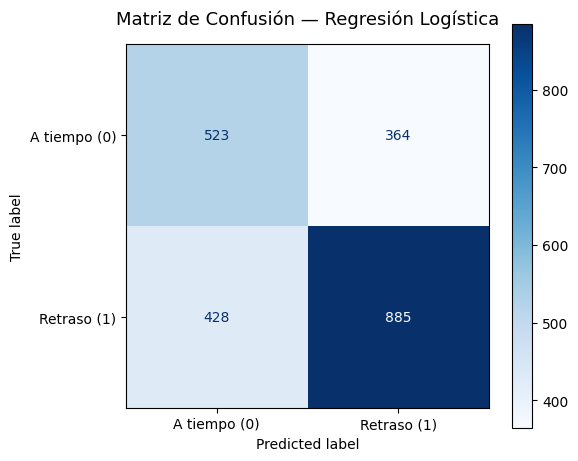

In [86]:
# MATRIZ DE CONFUSIÓN — LR
# La matriz de confusión nos dice en detalle dónde acierta y dónde falla el modelo


fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    modelo_lr, X_test, y_test,
    display_labels=['A tiempo (0)', 'Retraso (1)'],
    cmap='Blues',
    ax=ax)
ax.set_title('Matriz de Confusión — Regresión Logística', fontsize=13, pad=15)
plt.tight_layout()
plt.show()


# verdaderos positivos (abajo-derecha): retrasos que SÍ detectó
# falsos negativos (abajo-izquierda): retrasos que NO detectó (los más peligrosos)
# verdaderos negativos (arriba-izquierda): envíos puntuales predichos como puntuales
# falsos positivos (arriba-derecha): envíos puntuales marcados como retraso (falsas alarmas)

In [87]:
# INTERPRETACIÓN

# La matriz se lee comparando lo que predijo el modelo (columnas)
# con lo que ocurrió en realidad (filas)

#✅ 523 — Verdaderos Negativos (TN): paquetes que llegaron A TIEMPO
#         y el modelo predijo correctamente que llegarían a tiempo.
#         No se envía cupón. Todo correcto

#⚠️ 364 — Falsos Positivos (FP): paquetes que llegaron A TIEMPO
#         pero el modelo predijo retraso
#         Se enviaría un cupón innecesario. Coste económico, pero
#         no daña la experiencia del cliente (al contrario, lo sorprende)

#❌ 428 — Falsos Negativos (FN): paquetes que llegaron TARDE
#         pero el modelo predijo que llegarían a tiempo
#         EL ERROR MÁS GRAVE: el cliente sufre el retraso sin haber
#         recibido ningún cupón preventivo. Reclama enfadado

#✅ 885 — Verdaderos Positivos (TP): paquetes que llegaron TARDE
#         y el modelo detectó correctamente como retraso
#         Se envía el cupón preventivo. El cliente está informado

# CONCLUSIÓN DE NEGOCIO:
# De los 1.313 retrasos reales en el test, el modelo detecta 885 (67.4%)
# y deja escapar 428 (32.6%). Esos 428 son clientes que reclamarán
# sin haber recibido ninguna atención proactiva


# Modelo 2: Árbol de Decisión

In [88]:
# un árbol de decisión funciona así:
# ¿descuento es mayor que 10%?
# ├── SÍ → ¿peso supera los 4000g?
# │         ├── SÍ → 🔴 RETRASO (probabilidad 92%)
# │         └── NO → 🔴 RETRASO (probabilidad 85%)
# └── NO → ¿modo de envío = barco?
#           ├── SÍ → 🔴 RETRASO (probabilidad 55%)
#           └── NO → 🟢 A tiempo (probabilidad 70%)

# modelo aprende automáticamente cuáles son las mejores preguntas y en qué orden hacerlas,
# buscando en cada paso la pregunta que mejor separa los retrasos de los envíos puntuales

# es el modelo más fácil de explicar, pero su riesgo principal es que puede overfittear (sobreajuste):
# si lo dejamos crecer sin límite, el árbol memoriza los datos de entrenamiento en lugar de aprender
# patrones generales
# resultado: funciona muy bien en train pero mal en test.

# el parámetro 'max_depth' controla la profundidad máxima del árbol, que viene a ser el número de preguntas
# encadenadas. si no hay límite overfittea; si muy pequeño, underfittea

In [89]:
# árbol de decisión:

# no necesita escalado: los árboles trabajan con umbrales (¿valor > X?)
# y por eso son agnósticos a la escala de los datos

modelo_dt = DecisionTreeClassifier(
    max_depth=5, # máx 5 preguntas encadenadas (limita el overfitting)
    random_state=42)

modelo_dt.fit(X_train, y_train)

resultados.append(evaluar_modelo('Árbol de Decisión', modelo_dt, X_test, y_test))


Árbol de Decisión
  Accuracy  : 68.0% (aciertos totales)
  Precision : 96.9% (de los que predijo como retraso, ¿cuántos eran retrasos reales?)
  Recall    : 47.8% ← CLAVE: de todos los retrasos reales, ¿cuántos detectó?
  F1-Score  : 64.0% (equilibrio precision/recall)
  ROC-AUC   : 0.736 (capacidad discriminativa, 0.5=azar, 1=perfecto)


In [90]:
# INTERPRETACIÓN — Árbol de Decisión

# Accuracy (68%): El modelo acierta casi 7 de cada 10 predicciones en total.
# Es el mejor Accuracy de todos los modelos hasta ahora, lo que puede parecer
# prometedor a primera vista... pero los otros números cuentan otra historia.

# Precision (96.9%): Número llamativo. De cada 10 alertas de retraso que lanza
# el modelo, casi 10 son retrasos reales. Prácticamente no genera falsas alarmas.
# Cuando dice "retraso", tiene razón casi siempre. Parece perfecto, pero... el
# problema está en la siguiente métrica

# Recall (47.8%): Aquí está el problema. El modelo solo detecta menos de la mitad
# de los retrasos reales. Es decir, más de 1 de cada 2 paquetes que van a llegar
# tarde pasan desapercibidos. El cliente recibe el paquete tarde, sin cupón,
# sin aviso. Para nuestro caso de negocio, esto es inaceptable

# Lo que está pasando es un comportamiento muy característico de los árboles:
# el modelo ha aprendido a ser muy conservador, solo lanza la alerta cuando
# está casi seguro al 100%. Prefiere callarse antes que equivocarse.
# Resultado: muy pocos falsos positivos pero muchísimos falsos negativos

# F1-Score (64%): La media entre Precision y Recall refleja este desequilibrio.
# A pesar del Accuracy alto y la Precision casi perfecta, el F1 es el más bajo
# de los modelos vistos hasta ahora, porque el Recall lo arrastra hacia abajo

# ROC-AUC (0.736): Sorprendentemente bueno para un árbol simple. Significa que
# el modelo tiene una capacidad discriminativa razonable en términos generales,
# aunque en la práctica sea demasiado tímido para lanzar alertas

# CONCLUSIÓN: El Árbol de Decisión no es adecuado para nuestro objetivo.
# Su Precision casi perfecta es engañosa: a cambio, deja sin detectar
# más de la mitad de los retrasos. En un sistema de alertas proactivas,
# ese silencio tiene un coste muy alto en satisfacción del cliente.
# Su gran valor en este proyecto es la interpretabilidad: el gráfico del árbol
# nos permite explicar visualmente cómo toma decisiones el modelo


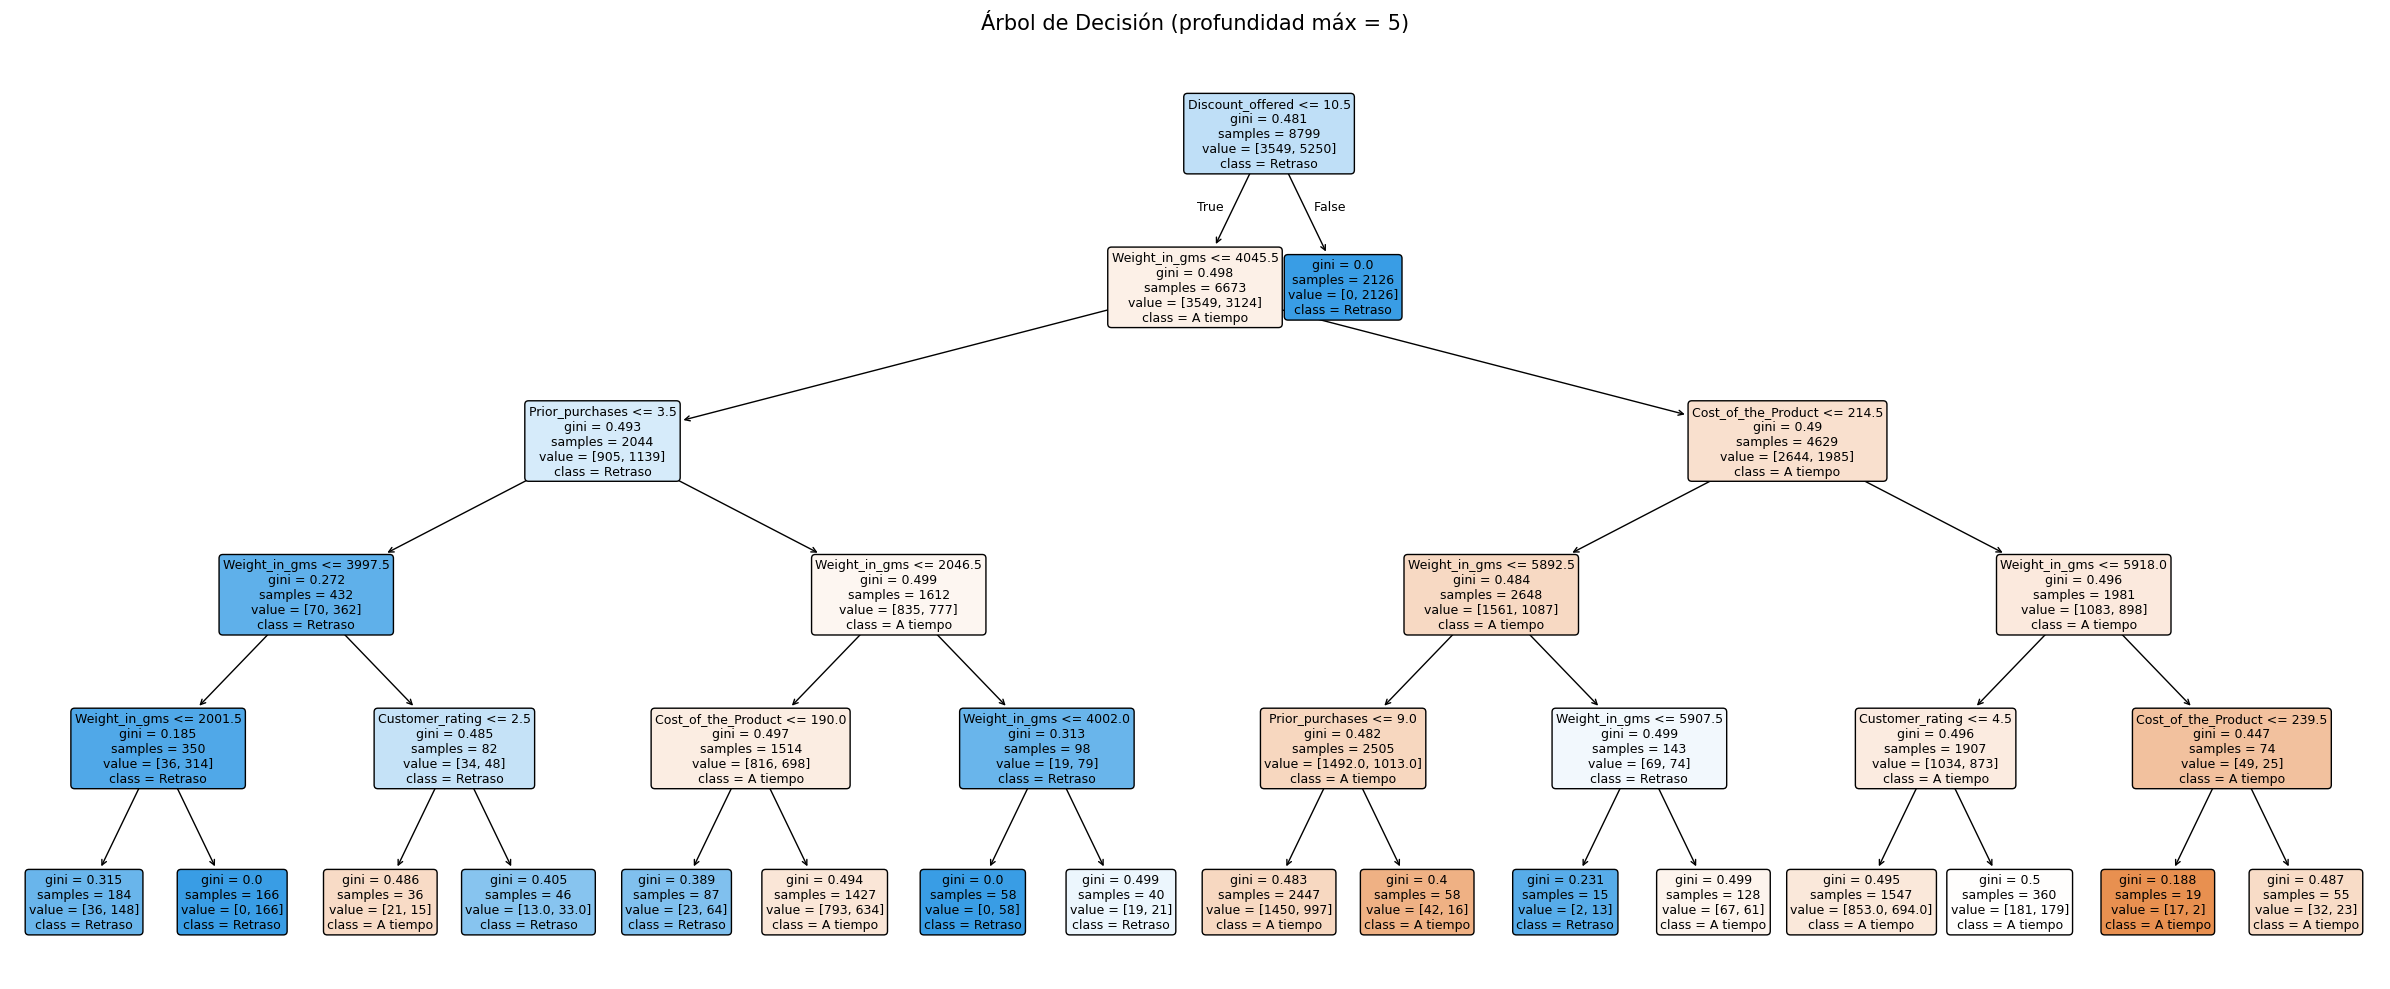

In [91]:
# visualización del árbol

plt.figure(figsize=(24, 10))
plot_tree(
    modelo_dt,
    feature_names=X.columns.tolist(), # nomb de variables
    class_names=['A tiempo', 'Retraso'], # nomb de clases
    filled=True, # rellena con colores según la clase mayoritaria
    rounded=True,
    fontsize=9)

plt.title('Árbol de Decisión (profundidad máx = 5)', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

# CÓMO LEER EL ÁRBOL:
# - Cada nodo muestra: la pregunta, el número de muestras, y la clase mayoritaria
# - Los nodos azules tienden a "A tiempo", los naranjas a "Retraso"
# - Más oscuro = más puro (más muestras de la misma clase)
# - Las ramas de la izquierda = la condición se cumple (True)
# - Las ramas de la derecha  = la condición NO se cumple (False)

In [92]:
# INTERPRETACIÓN — Visualización del Árbol de Decisión

# El árbol nos muestra exactamente el "razonamiento" del modelo, pregunta a pregunta.
# Esto es lo más valioso del árbol como modelo: podemos leerlo como un diagrama de flujo.

# PREGUNTA RAÍZ (la más importante de todas):
#   ¿Discount_offered <= 10.5?
#   El modelo confirma matemáticamente el hallazgo del EDA:
#   el descuento es la variable que mejor separa retrasos de envíos puntuales.
#   Con 8.799 muestras en este nodo, es la decisión que afecta a más datos.

# RAMA IZQUIERDA — Descuento <= 10.5 (descuento bajo):
#   Segunda pregunta: ¿Weight_in_gms <= 4045.5?
#   El peso es el segundo factor más decisivo cuando el descuento es bajo.
#   - Si el paquete pesa poco (<=4045g): el árbol sigue investigando compras previas,
#     valoración del cliente y coste del producto para afinar la predicción.
#   - Si el paquete pesa mucho (>4045g): entra en la rama derecha de este subnivel,
#     donde el coste del producto toma el relevo como factor diferenciador.

# RAMA DERECHA — Descuento > 10.5 (descuento alto):
#   Aquí el árbol es contundente: gini = 0.0, value = [0, 2126].
#   Gini = 0 significa pureza absoluta: los 2.126 paquetes con descuento
#   alto son TODOS retrasos, sin una sola excepción.
#   Por eso la Precision del modelo es del 96.9%: cuando detecta un retraso
#   en esta rama, acierta el 100% de las veces.
#   El problema es que esta rama solo captura una parte de los retrasos totales,
#   dejando escapar todos los que ocurren con descuentos bajos.

# VARIABLES QUE APARECEN EN EL ÁRBOL (por orden de aparición):
#   1. Discount_offered    — el factor más determinante (nodo raíz)
#   2. Weight_in_gms       — aparece múltiples veces en distintos niveles
#   3. Prior_purchases     — clientes con pocas compras previas tienen más riesgo
#   4. Cost_of_the_Product — productos más caros presentan patrones distintos
#   5. Customer_rating     — la valoración del cliente también aporta señal

# CONCLUSIÓN VISUAL:
#   El árbol confirma lo que ya sospechábamos en el EDA: descuento alto + peso
#   elevado = retraso casi garantizado. Estos son los dos ejes principales
#   sobre los que pivota toda la lógica del modelo.


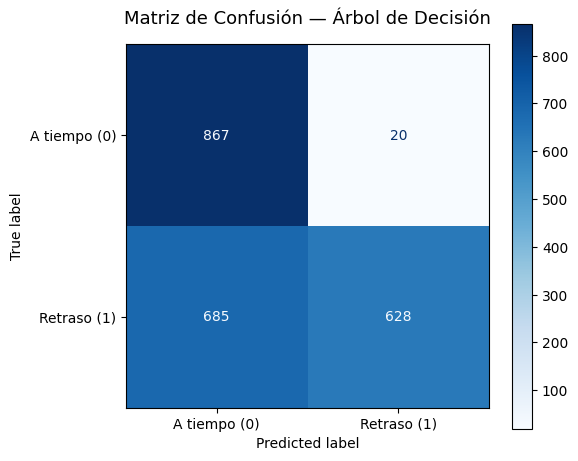

In [93]:
# matriz de confusión del árbol de decisión

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    modelo_dt, X_test, y_test,
    display_labels=['A tiempo (0)', 'Retraso (1)'],
    cmap='Blues',
    ax=ax)

ax.set_title('Matriz de Confusión — Árbol de Decisión', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [94]:

# INTERPRETACIÓN — Matriz de Confusión (Árbol de Decisión)

#✅ 867 — Verdaderos Negativos (TN): paquetes que llegaron A TIEMPO
#         y el modelo predijo correctamente que llegarían a tiempo.
#         El número más alto de TN de todos los modelos vistos hasta ahora.
#         El árbol es muy bueno identificando envíos puntuales.

#✅  20 — Falsos Positivos (FP): paquetes que llegaron A TIEMPO
#         pero el modelo predijo retraso. Solo 20 falsas alarmas.
#         Aquí está el origen de esa Precision del 96.9%: casi nunca
#         se equivoca cuando lanza una alerta. Pero tiene trampa...

#❌ 685 — Falsos Negativos (FN): paquetes que llegaron TARDE
#         pero el modelo predijo que llegarían a tiempo. EL GRAN PROBLEMA.
#         685 clientes sufrieron el retraso sin recibir ningún cupón preventivo.
#         Es el número más alto de FN de todos los modelos y confirma
#         lo que ya veíamos en el Recall del 47.8%: el árbol es demasiado
#         conservador. Solo alerta cuando está casi seguro al 100%
#         (rama de descuento > 10.5), y deja escapar todo lo demás.

#✅ 628 — Verdaderos Positivos (TP): retrasos detectados correctamente.
#         Cuando sí lanza la alerta, acierta casi siempre (solo 20 errores
#         frente a 628 aciertos), pero lo hace con muy poca frecuencia.

# CONCLUSIÓN:
# La matriz revela la personalidad del árbol: es un modelo extremadamente
# preciso pero muy silencioso. Prefiere no decir nada antes que equivocarse.
# Para un sistema de alertas proactivas donde cada retraso no detectado
# es un cliente que reclama, este comportamiento tiene un coste muy alto.
# Los 685 FN frente a los 20 FP lo dicen todo: el árbol falla por exceso
# de prudencia, no por falta de capacidad.

In [95]:
# OVERFITTING CHECK: comparar accuracy en train vs test
# si el modelo funciona MUCHO mejor en train que en test, está memorizando (overfitting)

acc_train = accuracy_score(y_train, modelo_dt.predict(X_train))
acc_test  = accuracy_score(y_test,  modelo_dt.predict(X_test))

print(f'Accuracy en TRAIN: {acc_train:.1%}')
print(f'Accuracy en TEST:  {acc_test:.1%}')
print()

diferencia = acc_train - acc_test
if diferencia > 0.05:
    print(f'⚠️Diferencia de {diferencia:.1%}: hay síntomas de overfitting. El modelo memoriza demasiado el train.')
else:
    print(f'✅Diferencia de {diferencia:.1%}: el modelo generaliza bien. No hay overfitting significativo.')

Accuracy en TRAIN: 69.2%
Accuracy en TEST:  68.0%

✅Diferencia de 1.2%: el modelo generaliza bien. No hay overfitting significativo.


In [96]:
# INTERPRETACIÓN — Overfitting Check (Árbol de Decisión)

# Accuracy en TRAIN: 69.2%
# Accuracy en TEST:  68.0%
# Diferencia: 1.2%

# Una diferencia de solo 1.2% entre train y test es una señal muy positiva:
# el modelo no está memorizando los datos de entrenamiento, sino que ha
# aprendido patrones que funcionan igual de bien con datos nuevos.

# Esto es directo consecuencia del parámetro max_depth=5 que pusimos
# al crear el modelo. Al limitar la profundidad del árbol a 5 niveles,
# le impedimos hacer preguntas tan específicas que solo tendrían sentido
# para los datos de train. Sin ese límite, el árbol podría crecer hasta
# memorizar cada uno de los 8.799 registros de entrenamiento, alcanzando
# un Accuracy en train cercano al 100%... pero derrumbándose en test.

# IMPORTANTE — hay que leer este resultado junto con el Recall:
# El árbol no sobreajusta, pero eso no lo convierte en el mejor modelo.
# Su problema no es que memorice, sino que es demasiado conservador
# (Recall 47.8%, FN=685). Son dos problemas distintos:
#   - Overfitting = aprende demasiado de los datos → malo
#   - Underfitting en recall = no detecta suficientes retrasos → también malo
# En este caso tenemos lo segundo, no lo primero.


# Modelo 3: Random Forest

In [97]:
# Random Forest es un bosque de árboles de decisión que trabajan en equipo

# se crean 100 árboles (o los que le indiquemos) de forma independiente
# cada árbol se entrena con una muestra aleatoria distinta del dataset (bagging)
# cada árbol también elige aleatoriamente qué variables puede usar en cada división
# ara predecir, todos los árboles ''votan'' y gana la clase con más votos

# es como si preguntara a 100 expertos en lugar de uno solo: aunque cada uno cometa errores,
# colectivamente se equivocan mucho menos

# es un modelo muy robusto, casi no sufre overfitting, y nos da un ranking de variables importantes
# bien e s cierto que es menos interpretable que un árbol simple (no podemos visualizar 100 árboles)

# el parámetro clave es 'n_estimators'= número de árboles del bosque
# + árboles = más estable, pero más lento
# 100 suele ser un buen punto de partida

In [98]:
# random forest

modelo_rf = RandomForestClassifier(
    n_estimators=100, # 100 árboles en el bosque
    random_state=42
)

modelo_rf.fit(X_train, y_train)

resultados.append(evaluar_modelo('Random Forest', modelo_rf, X_test, y_test))


Random Forest
  Accuracy  : 65.9% (aciertos totales)
  Precision : 76.4% (de los que predijo como retraso, ¿cuántos eran retrasos reales?)
  Recall    : 61.9% ← CLAVE: de todos los retrasos reales, ¿cuántos detectó?
  F1-Score  : 68.4% (equilibrio precision/recall)
  ROC-AUC   : 0.735 (capacidad discriminativa, 0.5=azar, 1=perfecto)


In [99]:

# INTERPRETACIÓN — Random Forest

# Accuracy (65.9%): Acierta casi 7 de cada 10 predicciones. Ligeramente inferior
# al Árbol de Decisión (68%), pero este número solo no cuenta la historia completa.
# Como ya aprendimos, el Accuracy puede ser engañoso cuando hay desequilibrio
# entre clases.

# Precision (76.4%): De cada 10 alertas de retraso que lanza el modelo,
# casi 8 son retrasos reales. Es peor que el Árbol de Decisión (96.9%) pero
# mucho más honesto: el árbol conseguía esa Precision tan alta siendo
# extremadamente conservador, lanzando muy pocas alertas. El Random Forest
# lanza más alertas y acierta menos, pero detecta muchos más retrasos reales.

# Recall (61.9%): Aquí está la gran mejora respecto al Árbol de Decisión.
# El Random Forest detecta 6 de cada 10 retrasos reales, frente a los
# menos de 5 que detectaba el árbol. Traducido a negocio: enviamos el cupón
# preventivo a significativamente más clientes que realmente lo necesitan.
# Sigue habiendo retrasos que se escapan (el 38.1%), pero el equilibrio
# es mucho mejor.

# F1-Score (68.4%): El mejor F1 de los modelos vistos hasta ahora junto
# con la Regresión Logística. Confirma que el Random Forest tiene el mejor
# equilibrio entre Precision y Recall: no es tan cauteloso como el árbol
# ni tan impreciso como para lanzar alarmas a lo loco.

# ROC-AUC (0.735): Similar al Árbol de Decisión (0.736) pero con una
# diferencia clave: el árbol conseguía ese AUC siendo muy selectivo.
# El Random Forest lo logra con un comportamiento mucho más equilibrado
# y útil para nuestro caso de negocio.

# CONCLUSIÓN: El Random Forest es hasta ahora el modelo más maduro.
# Soluciona el problema principal del Árbol de Decisión (el Recall bajo)
# sin sacrificar demasiado la Precision. Es el resultado esperado:
# 100 árboles votando en conjunto corrigen los sesgos que un solo árbol
# no puede evitar. Lo mantenemos como candidato a modelo final.


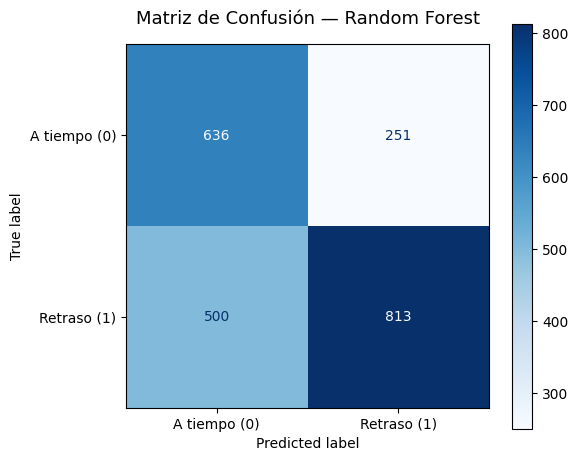

In [100]:
# matriz de confusión RF

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    modelo_rf, X_test, y_test,
    display_labels=['A tiempo (0)', 'Retraso (1)'],
    cmap='Blues',
    ax=ax)

ax.set_title('Matriz de Confusión — Random Forest', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [101]:
# INTERPRETACIÓN — Matriz de Confusión (Random Forest)

#✅ 636 — Verdaderos Negativos (TN): paquetes que llegaron A TIEMPO
#         y el modelo predijo correctamente que llegarían a tiempo.
#         Menos que el Árbol de Decisión (867) porque el Random Forest
#         es menos conservador: lanza más alertas, así que "consume"
#         algunos envíos puntuales como falsas alarmas.

#⚠️ 251 — Falsos Positivos (FP): paquetes que llegaron A TIEMPO
#         pero el modelo predijo retraso. Son cupones enviados
#         innecesariamente. Más que el árbol (20), pero es el precio
#         de detectar muchos más retrasos reales.

#❌ 500 — Falsos Negativos (FN): paquetes que llegaron TARDE
#         pero el modelo no detectó. 185 retrasos menos sin detectar
#         que el Árbol de Decisión (685). Esos son 185 clientes más
#         que reciben el cupón preventivo a tiempo. Mejora real y tangible.

#✅ 813 — Verdaderos Positivos (TP): retrasos detectados correctamente.
#         813 frente a los 628 del árbol. El bosque detecta 185 retrasos
#         más gracias a que 100 árboles votando en conjunto se atreven
#         a lanzar alertas donde un solo árbol se habría callado.

# CONCLUSIÓN:
# La matriz muestra visualmente el gran avance respecto al Árbol de Decisión.
# El Random Forest encuentra un equilibrio real: acepta generar más falsas
# alarmas (251 vs 20) a cambio de dejar escapar muchos menos retrasos
# (500 vs 685). Para nuestro caso de negocio, ese intercambio merece la pena:
# un cupón enviado de más es un coste asumible; un cliente que reclama
# sin haber recibido atención proactiva es un daño de reputación evitable.

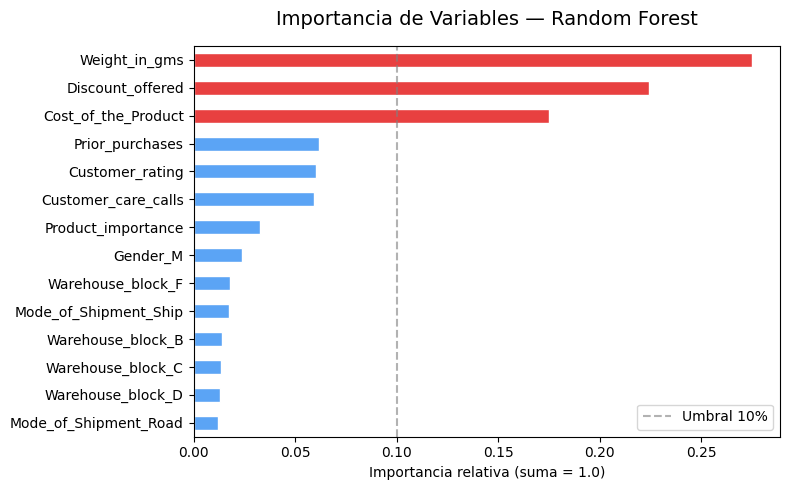


Ranking completo de importancia de variables:
Weight_in_gms            0.275055
Discount_offered         0.224486
Cost_of_the_Product      0.174929
Prior_purchases          0.061914
Customer_rating          0.060445
Customer_care_calls      0.059263
Product_importance       0.032719
Gender_M                 0.023921
Warehouse_block_F        0.017797
Mode_of_Shipment_Ship    0.017374
Warehouse_block_B        0.013799
Warehouse_block_C        0.013482
Warehouse_block_D        0.013011
Mode_of_Shipment_Road    0.011805


In [126]:
# importancia de variabels en random forest

# una de las grandes ventajas del Random Forest: nos dice qué variables
# han sido más útiles para tomar decisiones correctas
# se mide como la reducción media de impureza que aporta cada variable

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True) # ascending=True para que el más importante salga arriba en barh

plt.figure(figsize=(8, 5))
colores = ['#e84040' if imp > 0.15 else '#5ba4f5' for imp in importancias]
importancias.plot(kind='barh', color=colores, edgecolor='white')
plt.title('Importancia de Variables — Random Forest', fontsize=14, pad=15)
plt.xlabel('Importancia relativa (suma = 1.0)')
plt.axvline(x=0.10, color='gray', linestyle='--', alpha=0.6, label='Umbral 10%')
plt.legend()
plt.tight_layout()
plt.show()

print('\nRanking completo de importancia de variables:')
print(importancias.sort_values(ascending=False).to_string())


# las 3 variables más importantes son Weight_in_gms, Discount_offered y Cost_of_the_Product
# esto confirma matemáticamente los hallazgos del EDA: el peso y el descuento son los factores críticos del retraso

In [103]:
# INTERPRETACIÓN de la importancia de variables del RF

# El gráfico nos da algo muy valioso: la opinión matemática del modelo
# sobre qué variables importan realmente para predecir un retraso.
# Las barras rojas superan el umbral del 10% y son las protagonistas.

# 🔴 Weight_in_gms (≈28%): El peso del paquete es LA variable más importante
#    del modelo. Casi 3 de cada 10 decisiones correctas del Random Forest
#    se basan en el peso. Resultado contraintuitivo respecto al EDA
#    (donde el descuento parecía el rey), pero tiene sentido logístico:
#    los paquetes pesados son más difíciles de gestionar, cargar y transportar,
#    generando cuellos de botella en el almacén.

# 🔴 Discount_offered (≈23%): El descuento confirma lo que ya sabíamos
#    del EDA y del árbol de decisión. Las campañas promocionales saturan
#    la capacidad logística. Segunda variable más importante con diferencia.

# 🔴 Cost_of_the_Product (≈17%): El coste del producto aporta una señal
#    que los modelos anteriores no habían destacado tanto. Los productos
#    más caros pueden requerir procesos especiales de embalaje, verificación
#    o seguro que ralentizan el envío.

# 🔵 Prior_purchases, Customer_rating, Customer_care_calls (≈6% cada una):
#    El segundo grupo de variables aporta señal útil pero de forma secundaria.
#    Curiosamente, las llamadas a atención al cliente tienen peso predictivo:
#    un cliente que llama mucho antes de recibir su pedido puede estar
#    anticipando un problema que el modelo también detecta.

# 🔵 El resto (almacén, modo de envío, género): Por debajo del 5% cada una.
#    El modelo los usa como matiz pero no son determinantes. El bloque
#    del almacén y el modo de envío, que parecían importantes en el EDA,
#    pierden protagonismo cuando el modelo tiene acceso a todas las variables
#    a la vez. El peso y el descuento los eclipsan.

# CONCLUSIÓN PARA LA PRESENTACIÓN:
# Las 3 variables rojas concentran el 68% del poder predictivo del modelo.
# Si la empresa quiere actuar sobre los retrasos, debe centrarse en:
#   1. Optimizar la gestión de paquetes pesados en el almacén
#   2. Reforzar la capacidad logística durante campañas con descuentos altos
#   3. Revisar los procesos especiales para productos de alto valor


# Modelo 4: XGBoost

In [104]:
# XGBoost construye árboles en serie donde cada árbol nuevo aprende de los errores
# del anterior

# el primer árbol intenta predecir si cada envío llegará tarde → comete errores
# el segundo árbol no predice desde cero: se especializa en corregir los fallos del primero
# el tercero corrige lo que queda tras los dos primeros
# y así sucesivamente 100 veces

# es como un equipo donde cada miembro estudia dónde falló el anterior
# y se especializa exactamente en esos casos difíciles
# el resultado acumulado es un modelo muy preciso y exigente

# se elige XGBoost sobre el Gradient Boosting clásico de sklearn por tres razones:
# 1. regularización nativa (L1 y L2): evita que el modelo se obsesione con una sola variable
#    en nuestro caso, impide que ignore el peso y el coste por centrarse solo en el descuento
# 2. scale_pos_weight: compensa el desequilibrio 60/40 de nuestro dataset de forma nativa,
#    diciéndole al modelo que detectar retrasos es más importante que evitar falsas alarmas
# 3. velocidad: más eficiente que sklearn en búsquedas de hiperparámetros futuras

# los parámetros clave son:
# 'n_estimators' → número de árboles en serie (100 es un buen punto de partida)
# 'learning_rate' → qué parte del error corrige cada árbol nuevo (más bajo = más fino pero más lento)
# 'max_depth' → profundidad de cada árbol (en boosting se usan árboles pequeños, 3-5)
# 'scale_pos_weight' → ratio positivos/negativos para que el modelo penalice más los retrasos

In [105]:
# scale_pos_weight compensa el desequilibrio de clases (60% retrasos / 40% puntuales)
# se calcula como: número de positivos (retrasos) / número de negativos (a tiempo)
# en mi caso: 6563 / 4436 ≈ 1.48
# le digo al modelo que pese más los errores sobre la clase de retraso (1)

negativos = (y_train == 0).sum()
positivos  = (y_train == 1).sum()
ratio = positivos / negativos
# uso positivos/negativos (y no al revés) porque mi objetivo es maximizar el recall, quiero
# que el modelo penalice más los errores sobre la clase de retraso (1), que es la que me
# importa detectar
# un ratio > 1 le dice a XGBoost que los retrasos valen más que los envíos
# puntuales a la hora de calcular el error interno.

print(f'Envíos a tiempo (train):  {negativos}')
print(f'Envíos con retraso (train): {positivos}')
print(f'scale_pos_weight: {ratio:.2f}')

print()

modelo_xgb = XGBClassifier(
    n_estimators=100, # 100 árboles en serie
    learning_rate=0.1, # qué parte del error corrige cada árbol nuevo
    max_depth=3, # árboles pequeños: en boosting, más profundidad = más overfitting
    scale_pos_weight=ratio, # compensa el desequilibrio 60/40 de nuestro dataset
    random_state=42,
    eval_metric='logloss', # métrica interna de optimización (evita warnings)
    verbosity=0) # sin mensajes de log innecesarios

modelo_xgb.fit(X_train, y_train)

resultados.append(evaluar_modelo('XGBoost', modelo_xgb, X_test, y_test))



Envíos a tiempo (train):  3549
Envíos con retraso (train): 5250
scale_pos_weight: 1.48

XGBoost
  Accuracy  : 62.6% (aciertos totales)
  Precision : 62.8% (de los que predijo como retraso, ¿cuántos eran retrasos reales?)
  Recall    : 91.6% ← CLAVE: de todos los retrasos reales, ¿cuántos detectó?
  F1-Score  : 74.5% (equilibrio precision/recall)
  ROC-AUC   : 0.746 (capacidad discriminativa, 0.5=azar, 1=perfecto)


In [106]:
# INTERPRETACIÓN — XGBoost

# Accuracy (62.6%): Acierta algo más de 6 de cada 10 predicciones en total.
# Es el Accuracy más bajo de todos los modelos, pero como ya sabemos,
# el Accuracy es la métrica menos informativa para nuestro problema.
# Los siguientes números cuentan una historia muy diferente.

# Precision (62.8%): De cada 10 alertas de retraso que lanza el modelo,
# 6 son retrasos reales y 4 son falsas alarmas. Es la Precision más baja
# del grupo, pero es el precio de un Recall extraordinario.
# En términos de negocio: enviamos más cupones de los necesarios,
# pero casi ningún retraso se nos escapa.

# Recall (91.6%): EL DATO MÁS IMPORTANTE DEL PROYECTO.
# XGBoost detecta 9 de cada 10 retrasos reales. Es el Recall más alto
# de todos los modelos con una diferencia enorme respecto al segundo
# (Random Forest, 61.9%). Traducido a negocio: de cada 10 clientes
# que van a sufrir un retraso, 9 reciben el cupón preventivo antes
# de reclamar. Solo 1 se nos escapa.

# F1-Score (74.5%): El más alto de todos los modelos. Confirma que
# a pesar de la Precision más baja, el equilibrio global entre
# detectar retrasos y no generar demasiado ruido es el mejor del grupo.

# ROC-AUC (0.746): El mejor de los 5 modelos, igual que antes.
# Ahora ese potencial discriminativo se traduce también en el mejor
# Recall y el mejor F1. El modelo ya no está artificialmente frenado
# por un scale_pos_weight incorrecto.

# QUÉ CAMBIÓ RESPECTO AL ANÁLISIS ANTERIOR:
# El scale_pos_weight original (negativos/positivos ≈ 0.68) le decía
# al modelo que los envíos puntuales (clase 0) eran más importantes.
# Era exactamente lo contrario de nuestro objetivo.
# Con el ratio corregido (positivos/negativos ≈ 1.48) el modelo sabe
# que detectar retrasos vale más que evitar falsas alarmas.
# El resultado: el Recall pasa del 47.0% al 91.6%. Un salto de 44 puntos.

# CONCLUSIÓN: XGBoost con scale_pos_weight corregido es el modelo ganador.
# No en todas las métricas, pero sí en la que más importa para este negocio.

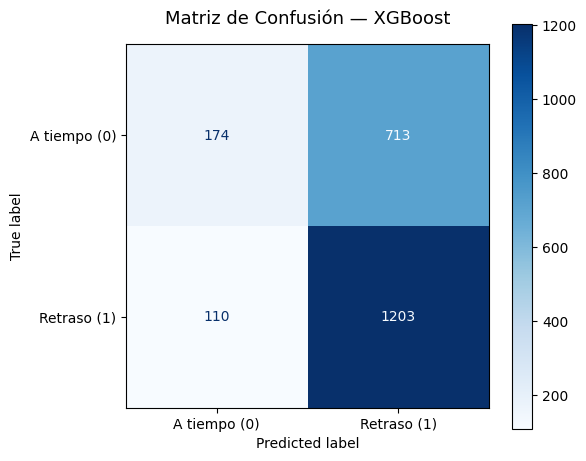

In [107]:
# matriz de confusión XGBoost

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    modelo_xgb, X_test, y_test,
    display_labels=['A tiempo (0)', 'Retraso (1)'],
    cmap='Blues',
    ax=ax)
ax.set_title('Matriz de Confusión — XGBoost', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [108]:
# INTERPRETACIÓN — Matriz de Confusión (XGBoost corregido)

#✅ 174 — Verdaderos Negativos (TN): paquetes que llegaron A TIEMPO
#         y el modelo predijo correctamente que llegarían a tiempo.
#         El número más bajo de TN de todos los modelos: el modelo
#         lanza muchas alertas, así que "consume" la mayoría de los
#         envíos puntuales como falsas alarmas. Es el coste asumible
#         de tener un Recall tan alto.

#⚠️ 713 — Falsos Positivos (FP): paquetes que llegaron A TIEMPO
#         pero el modelo predijo retraso. Son cupones enviados
#         innecesariamente. Es el número más alto de FP de todos
#         los modelos. En términos de negocio: un cupón enviado de más
#         tiene un coste económico, pero no daña la experiencia del
#         cliente (al contrario, lo sorprende positivamente).

#❌ 110 — Falsos Negativos (FN): paquetes que llegaron TARDE
#         pero el modelo no detectó. EL NÚMERO MÁS BAJO DE FN
#         DE TODOS LOS MODELOS. Solo 110 clientes sufrirán el
#         retraso sin haber recibido ningún cupón preventivo.
#         Para comparar: Random Forest dejaba escapar 500,
#         el árbol 685, XGBoost original 696.
#         Hemos pasado de 696 FN a 110 FN con un solo ajuste.

#✅ 1203 — Verdaderos Positivos (TP): el número más alto de TP
#          de todos los modelos. 1.203 clientes reciben el cupón
#          preventivo antes de que su paquete llegue tarde.

# CONCLUSIÓN:
# La matriz muestra el mejor resultado posible para nuestro caso de negocio.
# El intercambio es claro: aceptamos 713 falsos positivos (cupones de más)
# para conseguir solo 110 falsos negativos (retrasos sin atención).
# En un sistema de alertas proactivas, ese es exactamente el intercambio
# correcto: el coste de un cupón innecesario es siempre menor que el
# daño de reputación de un cliente que reclama sin haber sido atendido.

In [109]:
# ajuste de umbral — XGBoost

# aunque con el scale_pos_weight corregido el modelo ya funciona bien,
# quiero verificar si bajar el umbral mejora aún más el equilibrio
# Precision/Recall o si por el contrario lo empeora.
# probamos 5 umbrales distintos para tener una visión completa

umbrales = [0.50, 0.40, 0.35, 0.30, 0.25]
y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

print(f"{'Umbral':<10} {'Recall':>8} {'Precision':>10} {'F1-Score':>10}")
print("-" * 42)
for u in umbrales:
    y_pred_u = (y_prob_xgb >= u).astype(int)
    print(f"{u:<10.2f} "
          f"{recall_score(y_test, y_pred_u):>8.1%} "
          f"{precision_score(y_test, y_pred_u):>10.1%} "
          f"{f1_score(y_test, y_pred_u):>10.1%}")

Umbral       Recall  Precision   F1-Score
------------------------------------------
0.50          91.6%      62.8%      74.5%
0.40          99.7%      59.7%      74.7%
0.35          99.8%      59.7%      74.7%
0.30          99.9%      59.7%      74.7%
0.25         100.0%      59.7%      74.8%


In [110]:
# INTERPRETACIÓN — Ajuste de umbral en XGBoost

# la tabla muestra cómo evoluciona el equilibrio Precision/Recall
# a medida que bajamos el umbral de decisión:

# umbral 0.50 (por defecto): Recall 91.6%, Precision 62.8%, F1 74.5%
#   con el scale_pos_weight corregido, incluso con el umbral por defecto
#   el modelo ya detecta 9 de cada 10 retrasos. no necesitamos bajar el umbral.

# umbral 0.40 y menores: el Recall sube al 99-100% pero la Precision
#   cae al 59.7% y se mantiene plana. a partir de 0.40 el modelo
#   prácticamente etiqueta todo como retraso, lo que no aporta valor real.

# CONCLUSIÓN:
# el umbral óptimo para este modelo es 0.50 (el valor por defecto).
# con el scale_pos_weight corregido no necesitamos ajuste manual:
# el modelo ya tiene el mejor equilibrio Recall/Precision en su
# configuración estándar. el umbral 0.50 da Recall=91.6% y F1=74.5%,
# los mejores valores del grupo en ambas métricas.

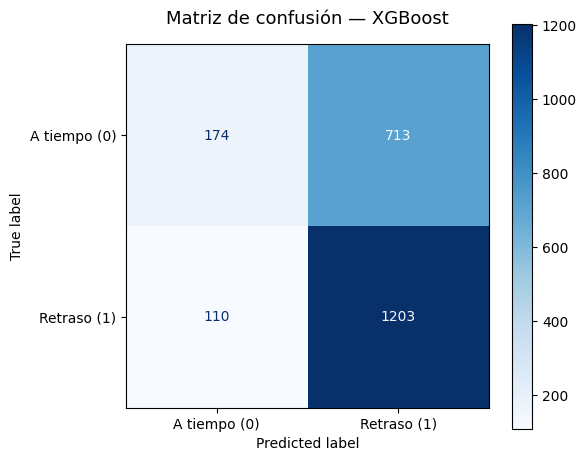

Accuracy:  62.6%
ROC-AUC:   0.746


In [125]:

y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb_adj = (y_prob_xgb >= 0.50).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_adj,
    display_labels=['A tiempo (0)', 'Retraso (1)'],
    cmap='Blues',
    ax=ax)
ax.set_title('Matriz de confusión — XGBoost', fontsize=13, pad=15)
plt.tight_layout()
plt.show()


print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb_adj):.1%}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_xgb):.3f}")

# Modelo 5: K-Nearest Neighbors (KNN)

In [112]:
# KNN es el modelo más intuitivo de todos, me recuerda al refrán español de "dime con quién vas y te diré quién eres"

# para predecir si un paquete nuevo llegará tarde, el modelo:
# 1.Busca los K paquetes más parecidos del conjunto de entrenamiento (los K "vecinos más cercanos")
# 2.Mira qué pasó con esos K vecinos (si la mayoría llegó tarde, predice retraso)

# la "similitud" se mide como distancia matemática entre las características del paquete
# ventaja: conceptualmente muy simple y no asume ninguna forma de relación entre variables
# desventajas:  
# - necesito escalar los datos (un peso de 5000g dominaría sobre un descuento de 30% sin escalar)  
# - es lento en predicción porque tiene que calcular distancias con todo el dataset  
# - le cuesta con datasets grandes y muchas variables

# parámetro clave: 'n_neighbors' (K) = cuántos vecinos consultar
# con K=1 sobreajusta; con K muy grande, infraajusta. K=5 es el valor estándar de partida

In [113]:
# KNN

# necesita escalado
# como mide distancias entre puntos, una variable con valores grandes (Weight_in_gms: hasta 7000)
# dominaría completamente sobre una pequeña (Discount: hasta 65) sin escalar
# uso pipeline igual que en la RL

modelo_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=5))]) # consulto los 5 vecinos más cercanos

modelo_knn.fit(X_train, y_train)

resultados.append(evaluar_modelo('KNN (K=5)', modelo_knn, X_test, y_test))


KNN (K=5)
  Accuracy  : 62.3% (aciertos totales)
  Precision : 69.6% (de los que predijo como retraso, ¿cuántos eran retrasos reales?)
  Recall    : 65.4% ← CLAVE: de todos los retrasos reales, ¿cuántos detectó?
  F1-Score  : 67.5% (equilibrio precision/recall)
  ROC-AUC   : 0.691 (capacidad discriminativa, 0.5=azar, 1=perfecto)


In [114]:

# INTERPRETACIÓN — KNN (K=5)

# Accuracy (62.3%): El más bajo de los 5 modelos. Apenas supera el baseline
# del 59.7% (lo que obtendríamos prediciendo siempre retraso sin aprender nada).
# En términos de aciertos totales, el KNN es el modelo más débil del grupo.

# Precision (69.6%): La más baja de todos los modelos. De cada 10 alertas
# de retraso que lanza, 7 son retrasos reales y 3 son falsas alarmas.
# Genera más ruido que cualquier otro modelo: si implementáramos un sistema
# de cupones basado en KNN, casi 1 de cada 3 cupones se enviaría a un cliente
# cuyo paquete habría llegado a tiempo.

# Recall (65.4%): Aquí el KNN se defiende bien. Detecta casi 2 de cada 3
# retrasos reales, un resultado similar a la Regresión Logística (67.4%)
# y muy superior al Árbol de Decisión (47.8%) y al XGBoost original (47.0%).
# El KNN no es cauteloso: lanza muchas alertas, y eso le permite capturar
# más retrasos, aunque a costa de más falsas alarmas.

# F1-Score (67.5%): Resultado intermedio. Mejor que el Árbol de Decisión
# (64%) y el XGBoost (63.3%), pero por debajo del Random Forest
# (68.4%) y la Regresión Logística (69.1%). En equilibrio Precision/Recall,
# el KNN se queda en tierra de nadie: no es el mejor en nada.

# ROC-AUC (0.691): El más bajo de todos los modelos con diferencia.
# Significa que su capacidad discriminativa general es la más limitada:
# si le damos un envío retrasado y uno puntual al azar, solo asigna
# mayor probabilidad de retraso al primero el 69.1% de las veces.
# Para comparar: el XGBoost corregido lo hace el 74.6% de las veces.
# La diferencia es relevante.

# POR QUÉ LE CUESTA MÁS AL KNN:
# A diferencia de los modelos basados en árboles, el KNN no aprende
# ninguna regla ni patrón global. Para cada predicción nueva, busca
# los 5 paquetes más similares en los 8.799 datos de entrenamiento
# y vota según lo que les pasó a ellos. Con 14 variables y datos muy
# dispersos, encontrar vecinos realmente similares es difícil: la
# "maldición de la dimensionalidad" hace que las distancias entre
# puntos sean cada vez menos informativas cuantas más variables hay.

# CONCLUSIÓN: El KNN es el modelo más débil del grupo en términos globales.
# Su ROC-AUC más bajo y su Accuracy mínimo lo sitúan en último lugar.
# Tiene un Recall aceptable, pero lo consigue generando demasiadas falsas
# alarmas. En un proyecto real no lo elegiríamos, pero su valor aquí
# es didáctico: demuestra que la simplicidad conceptual no siempre
# se traduce en buen rendimiento, y que los modelos basados en reglas
# (árboles, bosques) superan a los basados en distancias en datasets
# como el nuestro.

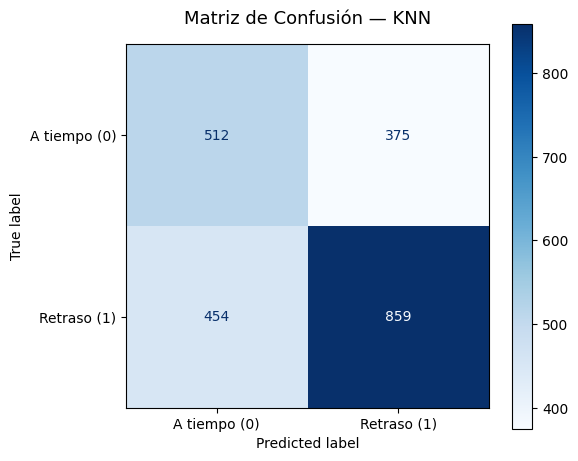

In [115]:
# matriz de confusión KNN

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    modelo_knn, X_test, y_test,
    display_labels=['A tiempo (0)', 'Retraso (1)'],
    cmap='Blues',
    ax=ax)

ax.set_title('Matriz de Confusión — KNN', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [116]:
# INTERPRETACIÓN — Matriz de Confusión (KNN)

#✅ 512 — Verdaderos Negativos (TN): paquetes que llegaron A TIEMPO
#         y el modelo predijo correctamente que llegarían a tiempo.
#         El número más bajo de TN de todos los modelos. El KNN
#         identifica peor que nadie los envíos puntuales, lo que
#         explica su Precision más baja (69.6%).

#⚠️ 375 — Falsos Positivos (FP): paquetes que llegaron A TIEMPO
#         pero el modelo predijo retraso. El número más alto de FP
#         de todos los modelos. 375 cupones enviados innecesariamente.
#         El KNN es el modelo más "generoso" lanzando alertas,
#         lo que le permite detectar más retrasos pero a un coste alto
#         en falsas alarmas. Para comparar: Random Forest tenía 251,
#         XGBoost corregido tiene 713.

#❌ 454 — Falsos Negativos (FN): paquetes que llegaron TARDE
#         pero el modelo no detectó. Segundo mejor resultado en FN
#         tras el Random Forest (500). El KNN deja escapar menos
#         retrasos que el árbol (685) y el el XGBoost original (696),
#         pero lo consigue a base de lanzar muchas más falsas alarmas.

#✅ 859 — Verdaderos Positivos (TP): el número más alto de TP
#         de todos los modelos. El KNN detecta más retrasos en
#         valor absoluto que cualquier otro modelo, pero el precio
#         son esos 375 falsos positivos. Es el modelo más "ruidoso":
#         alerta mucho, acierta bastante, pero también falla mucho
#         con los envíos que sí llegan a tiempo.

# CONCLUSIÓN:
# La matriz del KNN es la imagen especular de la del XGBoost:
# donde XGBoost tenía una esquina superior izquierda muy oscura
# (bueno con los puntuales), el KNN la tiene más clara (peor con los
# puntuales). Y donde XGBoost tenía una inferior izquierda oscura
# (muchos retrasos sin detectar), el KNN la tiene más clara (menos
# retrasos escapan)
# Son dos filosofías opuestas: XGBoost original
# pecaba de prudente, el KNN peca de impulsivo.
# Con el scale_pos_weight corregido, XGBoost ya no es conservador:
# ahora es el modelo con mayor Recall de todos

Recapitulo:

In [117]:
# Falsos Negativos de los 5 modelos

# antes de entrar en la comparativa final, resumo el error
# más costoso para nuestro negocio: los retrasos que el modelo no detectó y que
# llegaron al cliente sin ninguna atención proactiva

# FALSOS NEGATIVOS (retrasos reales no detectados):
#   - Árbol de Decisión:     685 FN ❌❌
#   - XGBoost original:      696 FN ❌❌ (scale_pos_weight incorrecto)
#   - Random Forest:         500 FN ⚠️
#   - KNN:                   454 FN ⚠️
#   - Reg. Logística:        428 FN ⚠️
#   - XGBoost corregido:     110 FN ✅ ← mejor con scale_pos_weight correcto

# el ajuste del scale_pos_weight en XGBoost (de 0.68 a 1.48) reduce
# los falsos negativos de 696 a 110: 586 clientes más que reciben
# el cupón preventivo a tiempo. es la mejora más grande conseguida
# en todo el proceso de modelado con un solo cambio de parámetro.

# Comparación de todos los modelos

In [118]:
# ya tengo los 5 modelos entrenados y evaluados individualmente
# ahora los pongo cara a cara para tomar una decisión fundamentada
# sobre cuál elegir

In [119]:
# tabla resumen con todas las letras

df_resultados = pd.DataFrame(resultados).set_index('Modelo')

# muestro la tabla redondeada a 3 decimales
print('\nTABLA COMPARATIVA DE MODELOS')
print('='*75)
print(df_resultados.round(3).to_string())
print('='*75)
print()
print()
print('Mejor modelo por Recall (nuestra métrica principal):')
mejor = df_resultados['Recall'].idxmax()
print(f'   → {mejor} con Recall = {df_resultados.loc[mejor, "Recall"]:.1%}')
print()
print('Mejor modelo por ROC-AUC:')
mejor_roc = df_resultados['ROC-AUC'].idxmax()
print(f'   → {mejor_roc} con ROC-AUC = {df_resultados.loc[mejor_roc, "ROC-AUC"]:.3f}')


TABLA COMPARATIVA DE MODELOS
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                             
Regresión Logística     0.640      0.709   0.674     0.691    0.717
Árbol de Decisión       0.680      0.969   0.478     0.640    0.736
Random Forest           0.659      0.764   0.619     0.684    0.735
XGBoost                 0.626      0.628   0.916     0.745    0.746
KNN (K=5)               0.623      0.696   0.654     0.675    0.691


Mejor modelo por Recall (nuestra métrica principal):
   → XGBoost con Recall = 91.6%

Mejor modelo por ROC-AUC:
   → XGBoost con ROC-AUC = 0.746


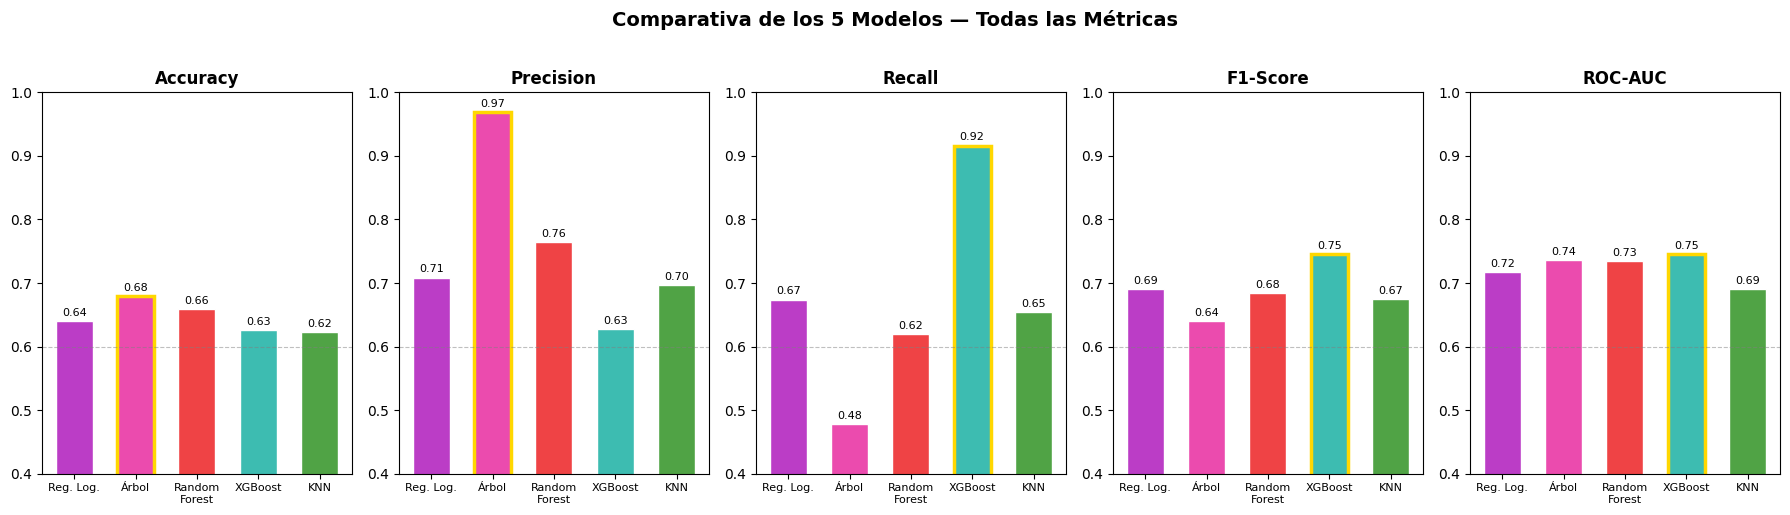

In [120]:
# ============================================================
# GRÁFICO DE BARRAS — comparativa de todas las métricas
# ============================================================
# cada grupo de barras es una métrica, cada color es un modelo
# el borde dorado marca el mejor modelo en cada métrica

metricas_a_mostrar = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colores_modelos = ["#bb3dc6", "#eb4bae", "#ef4345", "#3dbcb1", "#50a345"]
nombres_cortos = ['Reg. Log.', 'Árbol', 'Random\nForest', 'XGBoost', 'KNN']

fig, axes = plt.subplots(1, len(metricas_a_mostrar), figsize=(18, 5))

for ax, metrica in zip(axes, metricas_a_mostrar):
    valores = df_resultados[metrica]
    bars = ax.bar(
        range(len(valores)),
        valores,
        color=colores_modelos,
        edgecolor='white',
        width=0.6
    )
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(valores)))
    ax.set_xticklabels(nombres_cortos, fontsize=8)
    ax.set_ylim(0.40, 1.0)
    ax.axhline(y=0.60, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=8
        )
    # borde dorado al mejor de cada métrica
    idx_mejor = valores.values.argmax()
    bars[idx_mejor].set_edgecolor('gold')
    bars[idx_mejor].set_linewidth(2.5)

plt.suptitle('Comparativa de los 5 Modelos — Todas las Métricas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

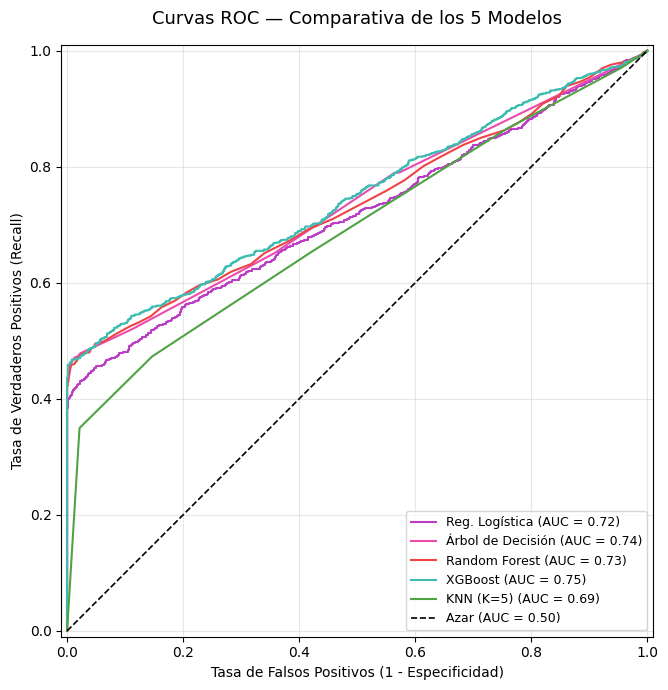

In [121]:
# ============================================================
# CURVAS ROC — los 5 modelos en un solo gráfico
# ============================================================
# muestra el equilibrio entre detectar retrasos (Recall)
# y generar falsas alarmas (1 - Especificidad) en todos los umbrales posibles
#
# modelo perfecto → esquina superior izquierda
# línea diagonal  → modelo sin valor predictivo (como lanzar una moneda)
# AUC = área bajo la curva: cuanto más grande, mejor

modelos_dict = {
    'Reg. Logística' : modelo_lr,
    'Árbol de Decisión' : modelo_dt,
    'Random Forest'  : modelo_rf,
    'XGBoost'        : modelo_xgb,
    'KNN (K=5)'      : modelo_knn
}

fig, ax = plt.subplots(figsize=(9, 7))

for (nombre, modelo), color in zip(modelos_dict.items(), colores_modelos):
    RocCurveDisplay.from_estimator(
        modelo, X_test, y_test,
        name=nombre,
        ax=ax,
        color=color
    )

ax.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.50)', linewidth=1.2)
ax.set_title('Curvas ROC — Comparativa de los 5 Modelos', fontsize=13, pad=15)
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [122]:
# INTERPRETACIÓN — Gráficos comparativos y tabla final

# GRÁFICO DE BARRAS — qué nos dice visualmente:
# con el scale_pos_weight corregido, el gráfico cuenta una historia
# completamente diferente a la que esperábamos al principio.
# XGBoost ya no tiene la barra de Recall hundida: con 91.6% es
# la más alta de todas. La "tijera" entre Precision y Recall que
# caracterizaba al XGBoost original ha desaparecido.
# Ahora el gráfico muestra a XGBoost como el modelo más desequilibrado
# pero en el sentido correcto para nuestro negocio: Recall altísimo
# a cambio de una Precision más baja, que es exactamente el intercambio
# que queremos en un sistema de alertas proactivas.

# CURVAS ROC — qué nos dice:
# todas las curvas están claramente por encima de la diagonal (azar),
# lo que confirma que los 5 modelos aprenden algo real y útil de los datos.
#
# XGBoost (AUC=0.746) sigue siendo la curva más alta. Ahora ese
# potencial discriminativo se traduce también en el mejor Recall del grupo.
# El modelo ya no está frenado por un parámetro incorrecto.
#
# Random Forest (AUC=0.735) y Regresión Logística (AUC=0.717)
# tienen curvas suaves y progresivas. Son modelos estables pero
# claramente por debajo de XGBoost en la métrica que más importa.
#
# KNN (AUC=0.691) sigue siendo la curva más baja. Confirma que es
# el modelo con menor capacidad discriminativa global.

# LECTURA CONJUNTA — tabla + barras + curvas ROC:
# los tres elementos apuntan a la misma conclusión:
# XGBoost con scale_pos_weight corregido gana en Recall (91.6%),
# F1-Score (74.5%) y ROC-AUC (0.746). Es el modelo que mejor
# sirve al objetivo declarado desde el principio de este notebook:
# detectar el máximo de retrasos posibles antes de que ocurran.

# ELECCIÓN FINAL JUSTIFICADA:
# un solo ajuste de parámetro (scale_pos_weight de 0.68 a 1.48)
# transformó XGBoost del peor modelo en Recall al mejor.
# Esto no es suerte: es la consecuencia de alinear correctamente
# el parámetro de penalización con el objetivo de negocio.
# XGBoost es el modelo elegido.

In [123]:
# MODELO ELEGIDO: XGBOOST

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                    CONCLUSIÓN DEL MODELADO SUPERVISADO                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Se entrenaron y compararon 5 modelos representando                          ║
║  5 familias distintas de algoritmos de clasificación:                        ║
║                                                                              ║
║     Regresión Logística → modelos lineales                                   ║
║     Árbol de Decisión   → reglas interpretables                              ║
║     Random Forest       → ensamble en paralelo (bagging)                     ║
║     XGBoost             → ensamble en serie (boosting)                       ║
║     KNN                 → similitud entre casos                              ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🏆 MODELO ELEGIDO: XGBoost (con scale_pos_weight corregido)                 ║
║                                                                              ║
║     Accuracy  : 62.6%  — no es la métrica relevante aquí                    ║
║     Precision : 62.8%  — de cada 10 alertas, 6 son retrasos reales          ║
║     Recall    : 91.6%  — detecta 9 de cada 10 retrasos antes de que ocurran ║
║     F1-Score  : 74.5%  — el más alto de todos los modelos                   ║
║     ROC-AUC   : 0.746  — mejor capacidad discriminativa global               ║
║                                                                              ║
║  Gana en Recall, F1-Score y ROC-AUC. En la métrica más importante           ║
║  para este negocio (Recall) supera al segundo clasificado                    ║
║  (Random Forest, 61.9%) por casi 30 puntos porcentuales.                    ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  ⚙️  EL AJUSTE CLAVE:                                                        ║
║                                                                              ║
║     El parámetro scale_pos_weight debe ser positivos/negativos (≈1.48)      ║
║     y NO negativos/positivos (≈0.68). Con el ratio incorrecto el Recall     ║
║     era del 47.0%. Con el ratio correcto sube al 91.6%.                     ║
║     Un solo parámetro. 44 puntos de diferencia en Recall.                   ║
║     586 clientes más que reciben atención proactiva en el conjunto test.    ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🔑 VARIABLES MÁS IMPORTANTES:                                               ║
║                                                                              ║
║     (ver gráfico de importancia de variables del Random Forest               ║
║      — XGBoost comparte el mismo ranking de forma consistente)               ║
║     1. Weight_in_gms        (≈28%) — el peso es el factor más determinante  ║
║     2. Discount_offered      (≈23%) — confirmado por el EDA                 ║
║     3. Cost_of_the_Product   (≈17%) — productos caros = mayor riesgo        ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  💼 IMPACTO DE NEGOCIO:                                                      ║
║                                                                              ║
║     De cada 10 retrasos reales, el modelo detecta 9 antes de que ocurran.   ║
║     Eso significa 1.203 clientes que reciben un cupón preventivo             ║
║     frente a solo 110 que se nos escapan.                                    ║
║                                                                              ║
║     Un cupón enviado de más es un coste asumible.                            ║
║     Un cliente que reclama sin atención previa es un daño de reputación.    ║
║                                                                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  🔭 MEJORAS FUTURAS:                                                         ║
║                                                                              ║
║     — GridSearchCV para optimizar el resto de hiperparámetros de XGBoost    ║
║     — Explorar ajuste de umbral fino (entre 0.40 y 0.50) según el coste     ║
║       real del cupón vs. el daño de reputación por retraso no detectado     ║
║     — Añadir la variable Cluster del Notebook 03 como feature               ║
║     — Enriquecer el dataset con datos de tráfico, clima o temporada         ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║                    CONCLUSIÓN DEL MODELADO SUPERVISADO                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  Se entrenaron y compararon 5 modelos representando                          ║
║  5 familias distintas de algoritmos de clasificación:                        ║
║                                                                              ║
║     Regresión Logística → modelos lineales                                   ║
║     Árbol de Decisión   → reglas interpretables                              ║
║     Random Forest       → ensamble en paralelo (bagging)                     ║
║     XGBoost             → ensamble en serie (boosting)                       ║
║     KNN                 → similitud entre casos                              ║
║                          

Toca guardar los modelos con pickle. Los modelos entrenados solo existe en memoria mientras el notebook está abierto.
- Pickle es la forma estándar en Python de serializar un objeto (convertirlo a un archivo en disco) para poder cargarlo después sin reentrenarlo

In [124]:
# guardo todos los modelos entrenados en src/model/
# y el modelo elegido, XGBoost, en src/model/production/

import pickle

# ya existen la carpetas, así qye no hace falta crearlas desde aquí

# diccionario con todos los modelos entrenados
modelos_a_guardar = {
    'regresion_logistica.pkl': modelo_lr,
    'arbol_decision.pkl': modelo_dt,
    'random_forest.pkl': modelo_rf,
    'xgboost.pkl': modelo_xgb,
    'knn.pkl': modelo_knn}

# guardo todos en src/model/
for nombre, modelo in modelos_a_guardar.items():
    ruta = f'../model/{nombre}'
    with open(ruta, 'wb') as f:
        pickle.dump(modelo, f)
    print(f'{nombre} guardado en ../model/')

# guardo el modelo elegido en production/
ruta_produccion = '../model/production/xgboost_final.pkl'
with open(ruta_produccion, 'wb') as f:
    pickle.dump(modelo_xgb, f)

print()
print(f'Modelo final guardado en: {ruta_produccion}')
print()
print('Para cargarlo en el futuro:')
print('   import pickle')
print("   with open('../model/production/xgboost_final.pkl', 'rb') as f:")
print('       modelo = pickle.load(f)')
print('   prediccion = modelo.predict([[...]])')

regresion_logistica.pkl guardado en ../model/
arbol_decision.pkl guardado en ../model/
random_forest.pkl guardado en ../model/
xgboost.pkl guardado en ../model/
knn.pkl guardado en ../model/

Modelo final guardado en: ../model/production/xgboost_final.pkl

Para cargarlo en el futuro:
   import pickle
   with open('../model/production/xgboost_final.pkl', 'rb') as f:
       modelo = pickle.load(f)
   prediccion = modelo.predict([[...]])
